# Importar Librerias Necesarias

In [1]:
import torch # para redes neuronales
import torch.nn as nn # para crear capas de redes neuronales
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Cargar y Explorar el Dataset de Billetes
El dataset tiene 6000 muestras (imagenes de billetes bolivianos) donde cada imagen es de 500x500 pixeles con 3 canales de color (RGB)

500x500x3 = 750.000 caracteristicas (pixeles) para el modelo, y tiene un total de 5 clases de billetes

etiequestas
- 0 = 10 bolivianos
- 1 = 20 bolivianos
- 2 = 50 bolivianos
- 3 = 100 bolivianos
- 4 = 200 bolivianos

con una distribucion balanceada (1200 muestras por cada clase)


In [2]:
# cargar el dataset desde el arcivo CSV
data = pd.read_csv('billetes_pixels_dataset.csv')

# mostrar la informacion del dataset
print('Forma del dataset:', data.shape)
print('Primeras 5 filas:')
print(data.head())
print('\Distribucion de clases:')
print(data['label'].value_counts())

Forma del dataset: (6000, 12289)
Primeras 5 filas:
   label  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      1        0        0        0        0        0        0        0   
1      3        0        0        0        0        0        0        0   
2      0        0        0        0        0        0        0        0   
3      1        0        0        0        0        0        0        0   
4      4        0        0        0        0        0        0        0   

   pixel_8  pixel_9  ...  pixel_12279  pixel_12280  pixel_12281  pixel_12282  \
0        0        0  ...            0            0            0            0   
1        0        0  ...            0            0            0            0   
2        0        0  ...            0            0            0            0   
3        0        0  ...            0            0            0            0   
4        0        0  ...            0            0            0            0   

   pixel_12283  p

# Separacion y Visualizacion de Muestras

Visualizando las primeras 10 muestras con formato RGB:


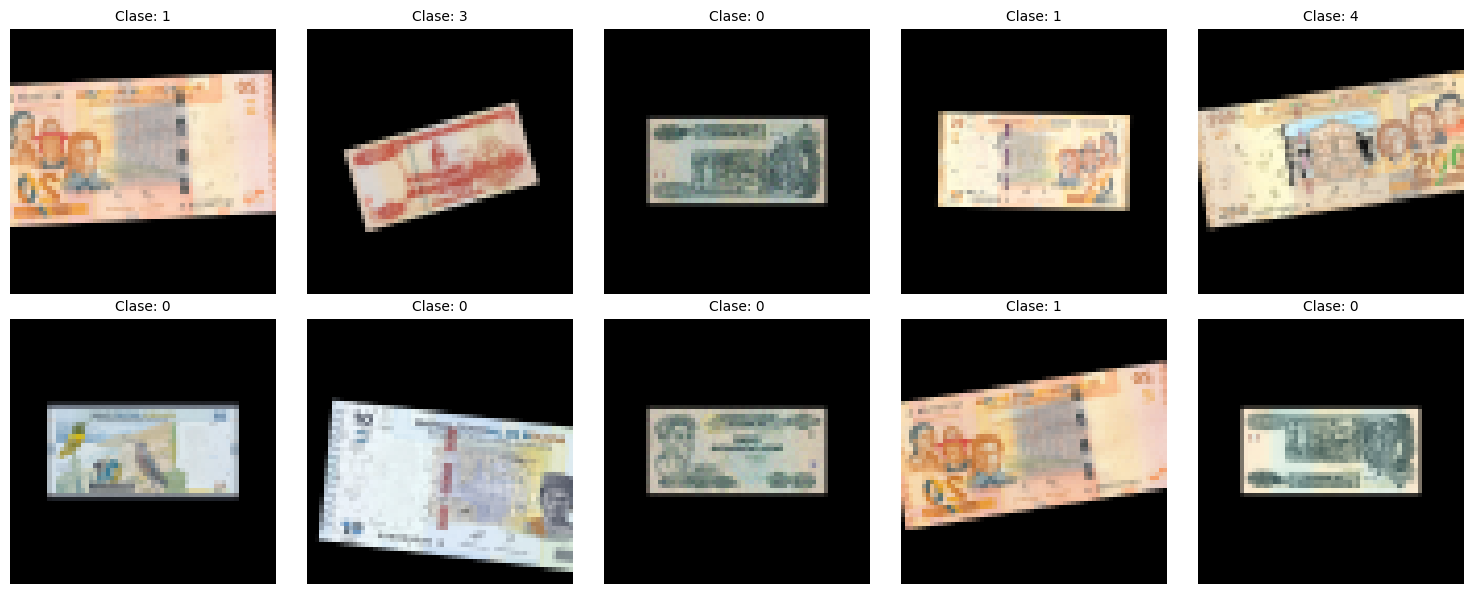

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- NUEVAS DIMENSIONES (Asunción de imagen a color 500x500) ---
IMG_ROWS = 500
IMG_COLS = 500
NUM_CHANNELS = 3 # RGB

# 1. Preparación de X y Y
X = data.drop('label', axis=1).values # Características (píxeles)
y = data['label'].values # Etiquetas

num_muestras_a_mostrar = 10
filas = 2
columnas = 5

plt.figure(figsize=(15, 6)) 
print("Visualizando las primeras 10 muestras con formato RGB:")

for i in range(num_muestras_a_mostrar):
    
    # a. Seleccionar y remodelar la imagen
    imagen_plana = X[i]
    # Remodelar de 750000 a 500x500x3 (Altura, Ancho, Canales)
    imagen_rgb = imagen_plana.reshape(IMG_ROWS, IMG_COLS, NUM_CHANNELS)
    
    # b. Crear el subplot
    plt.subplot(filas, columnas, i + 1)
    
    # c. Mostrar la imagen - ¡SIN usar cmap='gray'!
    plt.imshow(imagen_rgb.astype(np.uint8)) # Usar uint8 para mejor visualización si los valores originales no estaban normalizados
    
    # d. Título
    plt.title(f"Clase: {y[i]}", fontsize=10)
    plt.axis('off')

plt.tight_layout() 
plt.show()

# Separacion de Caracteristicas y Etiquetas
Separar la columna a predecir (label) del resto de las columnas (los pixeles) que se usaran para la prediccion

In [ ]:
# separar las caracteristicas (X) y las etiquetas (y)
X = data.drop('label', axis=1).values # todas las columnas de píxeles (750000)
y = data['label'].values # solo la columna 'label' (0, 1, 2, 3, 4)

print('Forma de X:', X.shape)
print('Forma de y', y.shape)

Forma de X: (6000, 12288)
Forma de y (6000,)


# Normalizacion de Pixeles

Escalar todos los pixeles de las imagenes de billetes en un rango entre 0.0 y 1.0

In [ ]:
# normalizar los valores de pixeles entre 0 y 1
X_normalized = X / 255.0 # valor del RGB rojo, azul y amarillo

print('Primeros 5 valores de píxel normalizados:', X_normalized[0, :5])

print('Valores minimos y maximos despues de normalizar:')
print('Minimo:', X_normalized.min())
print('Maximo:', X_normalized.max())

Primeros 5 valores de píxel normalizados: [0. 0. 0. 0. 0.]
Valores minimos y maximos despues de normalizar:
Minimo: 0
Maximo: 255


# Division en Conjuntos de Entrenamiento y Prueba
Separar parte de los datos en:
- 80% para entrenar la Red Neuronal
- 20% para evaluar las pruebas del modelo

In [ ]:
# Dividir el 80% para entrenamiento y el 20% para prueba.
# CRUCIAL: Usamos stratify=y para asegurar que las 5 clases mantengan su proporción balanceada.
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print('Forma de X_train (Entrenamiento):', X_train.shape)
print('Forma de X_test (Prueba):', X_test.shape)

Forma de X_train (Entrenamiento): (4800, 12288)
Forma de X_test (Prueba): (1200, 12288)


# Conversion de Datos a Tensores PyTorch
Convertir los arrays de Numpy (X_train, y_train, ...) en obetos de Tensor de PyTorch, para realuzar calculos eficientes usando la GPU

In [7]:
X_train_tensor = torch.from_numpy(X_train).float().cuda()
y_train_tensor = torch.from_numpy(y_train).long().cuda()
X_test_tensor = torch.from_numpy(X_test).float().cuda()
y_test_tensor = torch.from_numpy(y_test).long().cuda()


print('Tipo de X_train_tensor:', X_train_tensor.dtype)
print('\n--------------------')
print('Dispositivo de X_train_tensor:', X_train_tensor)

Tipo de X_train_tensor: torch.float32

--------------------
Dispositivo de X_train_tensor: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')


# Definicion de la Arquitectura de la Red Neuronal (Deep MLP)
Modelo de Red Neuronal Multicapa Profunda totalmente concectada (Full Connected) utilizando el modulo nn.Sequential de PyTorch

In [ ]:
# Definir los tamaños correctos para el dataset de billetes
input_size = 500*500*3 # 750000 características (píxeles)
output_size = 5     # 5 clases de billetes (0, 1, 2, 3, 4)

# Crear el modelo secuencial (Deep MLP con 8 capas ocultas)
model = nn.Sequential(
    nn.Linear(750000, 4096),  # Capa 1: reducción fuerte
    nn.ReLU(),
    nn.Linear(4096, 2048),    # Capa 2
    nn.ReLU(),
    nn.Linear(2048, 1024),    # Capa 3
    nn.ReLU(),
    nn.Linear(1024, 512),     # Capa 4
    nn.ReLU(),
    nn.Linear(512, 256),      # Capa 5
    nn.ReLU(),
    nn.Linear(256, 128),      # Capa 6
    nn.ReLU(),
    nn.Linear(128, 64),       # Capa 7
    nn.ReLU(),
    nn.Linear(64, output_size) # Capa de salida
).to(torch.device("cpu"))


print('Arquitectura del modelo Deep MLP:')
print(model)

Arquitectura del modelo Deep MLP:
Sequential(
  (0): Linear(in_features=12288, out_features=8192, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8192, out_features=4096, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4096, out_features=2048, bias=True)
  (5): ReLU()
  (6): Linear(in_features=2048, out_features=1024, bias=True)
  (7): ReLU()
  (8): Linear(in_features=1024, out_features=512, bias=True)
  (9): ReLU()
  (10): Linear(in_features=512, out_features=256, bias=True)
  (11): ReLU()
  (12): Linear(in_features=256, out_features=128, bias=True)
  (13): ReLU()
  (14): Linear(in_features=128, out_features=64, bias=True)
  (15): ReLU()
  (16): Linear(in_features=64, out_features=5, bias=True)
)


# Configuracion del Entrenamiento (Loss y Optimizador)
Establecer como el modelo medira el error al clasificar los billetes y como ajustara sus pesos internos para reducir el error a lo largo de las epocas, con el optimizador Adam

In [10]:
# definir la funcion de perdida (CrossEntropy para clasificacion multiclase)
criterion = nn.CrossEntropyLoss()

# definir el optimizador (adam con learning rate de 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('Funcion de perdida:', criterion)
print('Optimizador:', optimizer)

Funcion de perdida: CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Funcion de Evaluacion

In [11]:
def evaluate(model, X, y):
    """
    Función para evaluar el modelo en un conjunto de datos
    """
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():  # Desactivar cálculo de gradientes
        outputs = model(X)  # Forward 
        _, predicted = torch.max(outputs.data, 1)  # Obtener predicciones
        accuracy = accuracy_score(y.cpu(), predicted.cpu())  # Calcular accuracy
    model.train()  # Volver a modo entrenamiento
    return accuracy, predicted

# Bucle de Entrenamiento de la Red Neuronal
El modelos aprende a clasificar las imagenes de billetes a lo largo de 2000 epocas

In [12]:
# Hiperparámetros
num_epochs = 2000 # epocas o siglos
log_interval = 100 # mostrar de cuanto en cuanto

# Listas para guardar métricas
train_losses = []
test_accuracies = []

# Bucle de entrenamiento
for epoch in range(1, num_epochs + 1):
    # Modo entrenamiento
    model.train()
    
    # Forward (adelante)
    outputs = model(X_train_tensor) 
    loss = criterion(outputs, y_train_tensor) # calcular la funcion de perdida
    
    # Backward (atras) y optimización
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()        # Calcular gradientes
    optimizer.step()       # Actualizar pesos
    
    # Guardar pérdida
    train_losses.append(loss.item())
    
    # Evaluar cada log_interval épocas # _ nos vota dos valores solo utilizamos 1
    if epoch % log_interval == 0:
        test_accuracy, _ = evaluate(model, X_test_tensor, y_test_tensor)
        test_accuracies.append(test_accuracy)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}')

# Guardar resultados
Adam_train_losses = train_losses.copy()
Adam_test_accuracies = test_accuracies.copy()

Epoch [100/2000], Loss: 1.0321, Test Accuracy: 0.4933
Epoch [200/2000], Loss: 0.5649, Test Accuracy: 0.7025
Epoch [300/2000], Loss: 0.5551, Test Accuracy: 0.6992
Epoch [400/2000], Loss: 0.6172, Test Accuracy: 0.6425
Epoch [500/2000], Loss: 0.2402, Test Accuracy: 0.8892
Epoch [600/2000], Loss: 0.7774, Test Accuracy: 0.6083
Epoch [700/2000], Loss: 0.0096, Test Accuracy: 0.9600
Epoch [800/2000], Loss: 0.0005, Test Accuracy: 0.9625
Epoch [900/2000], Loss: 0.0001, Test Accuracy: 0.9608
Epoch [1000/2000], Loss: 0.0000, Test Accuracy: 0.9608
Epoch [1100/2000], Loss: 0.0000, Test Accuracy: 0.9608
Epoch [1200/2000], Loss: 0.0000, Test Accuracy: 0.9608
Epoch [1300/2000], Loss: 0.0000, Test Accuracy: 0.9592
Epoch [1400/2000], Loss: 0.0000, Test Accuracy: 0.9583
Epoch [1500/2000], Loss: 0.0000, Test Accuracy: 0.9592
Epoch [1600/2000], Loss: 0.0000, Test Accuracy: 0.9592
Epoch [1700/2000], Loss: 0.0000, Test Accuracy: 0.9592
Epoch [1800/2000], Loss: 0.0000, Test Accuracy: 0.9592
Epoch [1900/2000], 

# Evaluacion y Verificacion de Predicciones
Despues de las 2000 epocas de entrenamiento, comparar algunas predicciones con la realidad

In [2]:
# evalucacion final del modelo
final_accuracy, final_predictions = evaluate(model, X_test_tensor, y_test_tensor)
print(f'\Accuracy final en el test: {final_accuracy:.4f}')

# mostrar algunas predicciones vs reales
print('n\Algunas predicciones vs valores reales:')
for i in range(10):
    print(f'Prediccion" {final_predictions[i].item()}, Real: {y_test_tensor[i].item()}')

NameError: name 'evaluate' is not defined

# Guardado de Modelo
guarda los parametros aprendidos (pesos y sesgos) de la Reb Neurona, para luego porder utilizar en una infrencia, si se necesita clasificar nuevos billetes

In [14]:
# Guardar el modelo entrenado
torch.save(model.state_dict(), 'modelo_clasificacion.pth')
print('Modelo guardado como "modelo_clasificacion.pth"')

# Guardar también el optimizador para continuar entrenamiento luego
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, 'checkpoint_clasificacion.pth')

Modelo guardado como "modelo_clasificacion.pth"
